## Extraer características

El objetivo de este notebook es extraer las características necesarias entre el cuerpo de la noticia que puedan dar indicios de clickbait y ver si se diferencia en el espacio reducido con el UMAP

### Librerías

In [181]:
import spacy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import json
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity


import nltk
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize
from sentence_transformers import SentenceTransformer
from umap import UMAP


from sentence_transformers import CrossEncoder
from scipy.special import expit


import re
from nltk.tokenize import word_tokenize
from sklearn.preprocessing import StandardScaler

nltk.download("punkt")
nltk.download('stopwords')
nlp = spacy.load("es_core_news_sm")
stop = stopwords.words('spanish')


embedding_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-mpnet-base-v2") # paraphrase-multilingual-mpnet-base-v2 paraphrase-multilingual-MiniLM-L12-v2


[nltk_data] Downloading package punkt to /home/javier/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/javier/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1429.09it/s]


### Funciones principales

In [182]:
def dividir_contenido(texto, palabras_por_fragmento=15):
    palabras = texto.split()
    fragmentos = []
    for i in range(0, len(palabras), palabras_por_fragmento):
        fragmento = " ".join(palabras[i:i + palabras_por_fragmento])
        fragmentos.append(fragmento)
    return fragmentos

def cargar_datos(noticias, n_noticia=0, print_info=False):
    """
    Carga título y contenido de una noticia
    input: n_noticia (int): índice de noticia
    output: titulo, fragmentos_contenido (list)
    """
    noticia = noticias[n_noticia]
    titulo = noticia["Título"]
    contenido = noticia["Contenido"]
    # fragmentos_contenido = sent_tokenize(contenido, language='spanish')
    fragmentos_contenido = dividir_contenido(contenido, palabras_por_fragmento=15)
    if print_info:
        print(f"Título: {titulo}\n")
        print(f"\nFragmentos:")
        for i, frag in enumerate(fragmentos_contenido, 1):
            print(f"  Fragmento {i}: {frag}")
    
    return titulo, fragmentos_contenido,noticia


def extraer_features_linguisticos(corpus):
    """
    Extrae features lingüísticas relacionadas con clickbait.

    Parameters
    ----------
    corpus : list[str]
        Lista de textos.

    Returns
    -------
    np.ndarray
        Array shape (n_textos, n_features)
    """

    # =====================================================
    # Diccionarios léxicos
    # =====================================================

    deicticos = {
        'yo', 'tú', 'tu', 'usted', 'ustedes',
        'él', 'ella', 'ellos', 'ellas',
        'nosotros', 'nosotras',
        'vosotros', 'vosotras',
        'me', 'te', 'se', 'nos', 'os',
        'le', 'les',
        'mi', 'mis',
        'tus', 'su', 'sus',
        'nuestro', 'nuestra',
        'vuestro', 'vuestra',
        'este', 'esta', 'estos', 'estas',
        'ese', 'esa', 'esos', 'esas',
        'aquel', 'aquella',
        'aquí', 'ahí', 'allí',
        'ahora', 'hoy', 'mañana',
        'esto', 'eso', 'aquello'
    }

    intensificadores = {
        'muy', 'sumamente', 'extremadamente',
        'increíblemente', 'absolutamente',
        'totalmente', 'completamente',
        'realmente', 'verdaderamente',
        'demasiado', 'especialmente',
        'particularmente', 'sorprendentemente',
        'brutalmente', 'impresionantemente',
        'enormemente', 'terriblemente'
    }

    superlativos = {
        'mejor', 'peor', 'máximo', 'mínimo',
        'mayor', 'menor', 'último', 'primero',
        'buenísimo', 'malísimo',
        'importantísimo', 'gravísimo',
        'rarísimo', 'famosísimo',
        'enormísimo'
    }

    emocionales = {
        'increíble', 'impactante',
        'sorprendente', 'brutal',
        'impresionante', 'escandaloso',
        'alarmante', 'insólito',
        'inesperado', 'viral',
        'polémico', 'emocionante',
        'dramático', 'sorprendido',
        'devastador', 'terrible',
        'histórico', 'explosivo'
    }

    curiosity_gap = {
        'no creerás',
        'nadie esperaba',
        'lo que pasó',
        'te sorprenderá',
        'se vuelve viral',
        'está arrasando',
        'deja sin palabras',
        'causa furor',
        'no podrás creer',
        'todo el mundo habla',
        'revoluciona las redes',
        'se hace viral'
    }

    # =====================================================
    # Extracción de features
    # =====================================================

    features = []

    for texto in corpus:

        texto_lower = texto.lower()

        palabras = word_tokenize(
            texto_lower,
            language="spanish"
        )

        n_palabras = max(len(palabras), 1)

        # -----------------------------
        # Conteos léxicos
        # -----------------------------

        deicticos_count = sum(
            1 for p in palabras
            if p in deicticos
        )

        intensificadores_count = sum(
            1 for p in palabras
            if p in intensificadores
        )

        emocionales_count = sum(
            1 for p in palabras
            if p in emocionales
        )

        superlativos_count = sum(
            1 for p in palabras
            if (
                p in superlativos
                or any(
                    suf in p
                    for suf in [
                        'ísimo',
                        'ísima',
                        'ísimos',
                        'ísimas'
                    ]
                )
            )
        )

        # -----------------------------
        # Curiosity gap
        # -----------------------------

        curiosity_count = sum(
            1 for expr in curiosity_gap
            if expr in texto_lower
        )

        # -----------------------------
        # Puntuación
        # -----------------------------

        exclamaciones = len(
            re.findall(r'[!¡]', texto)
        )

        interrogaciones = len(
            re.findall(r'[?¿]', texto)
        )

        puntos_suspensivos = texto.count("...")

        mayusculas = len(
            re.findall(r'\b[A-ZÁÉÍÓÚÑ]{2,}\b', texto)
        )

        numeros = len(
            re.findall(r'\b\d+\b', texto)
        )

        # -----------------------------
        # Ratios normalizados
        # -----------------------------

        deicticos_ratio = deicticos_count / n_palabras
        intensificadores_ratio = intensificadores_count / n_palabras
        emocionales_ratio = emocionales_count / n_palabras
        superlativos_ratio = superlativos_count / n_palabras

        # -----------------------------
        # Vector final
        # -----------------------------

        features.append([
            deicticos_count,
            intensificadores_count,
            superlativos_count,
            emocionales_count,
            curiosity_count,
            exclamaciones,
            interrogaciones,
            # puntos_suspensivos,
            # mayusculas,
            # numeros,
            deicticos_ratio,
            intensificadores_ratio,
            emocionales_ratio,
            superlativos_ratio
        ])

    return np.array(features)


def calcular_diferencia_features(corpus):
    """
    Calcula diferencia de features entre título y fragmentos
    input: corpus (list): lista de textos
    output: diferencias (array), features normalizados (tuple)
    """
    
    features = extraer_features_linguisticos(corpus)
    
    scaler = StandardScaler()
    features_norm = scaler.fit_transform(features)
    
    titulo_norm = features_norm[0]
    fragmentos_norm = features_norm[1:]
    
    diferencias = np.linalg.norm(fragmentos_norm - titulo_norm, axis=1)
    
    return diferencias, (titulo_norm, fragmentos_norm)


# =========================
# LSA (reducción a 2D)
# =========================

def LSA_vectors(corpus,min_df=1,plot=False):
    tfidf_vectorizer = TfidfVectorizer(min_df=min_df)
    tfidf = tfidf_vectorizer.fit_transform(corpus)


    n_components = min(2, tfidf.shape[0] - 1)
    lsa = TruncatedSVD(n_components=n_components, random_state=42)
    tfidf_lsa = lsa.fit_transform(tfidf)
    titulo_vector = tfidf[0]
    fragmentos_vectors = tfidf[1:]
    similitudes = cosine_similarity(titulo_vector, fragmentos_vectors)[0]
    # if plot:
    #     plt.figure(figsize=(10, 6))
    #     colors = ['red'] + ['blue'] * len(fragmentos_contenido)
    #     labels = ['Título'] + [f'Frag {i+1}' for i in range(len(fragmentos_contenido))]

    #     plt.scatter(tfidf_lsa[:, 0], tfidf_lsa[:, 1], c=colors, s=100, alpha=0.6)
    #     for i, label in enumerate(labels):
    #         plt.annotate(label, (tfidf_lsa[i, 0], tfidf_lsa[i, 1]), fontsize=9, ha='center')

    #     plt.xlabel('LSA Component 1')
    #     plt.ylabel('LSA Component 2')
    #     plt.title('Distribución LSA: Título vs Fragmentos')
    #     plt.grid(True, alpha=0.3)
    #     plt.tight_layout()
    #     plt.show()

    return similitudes,tfidf_lsa



# ----------------------------
# ESPACIO EMBEDDING CON SENTENCE TRANSFORMERS
# ----------------------------


def embedding_sentence_transformers(corpus,embedding_model):
    embeddings = embedding_model.encode(
    corpus,
    show_progress_bar=True
    )
    titulo_embedding = embeddings[0]
    fragmentos_embeddings = embeddings[1:]

    similarities = cosine_similarity(
        [titulo_embedding],
        fragmentos_embeddings
    )[0]

    return similarities,embeddings

def embedding_umap(similarities,embeddings, plot=False):
    reducer = UMAP(
    n_neighbors = min(5, len(embeddings) - 1), # Pongo esto porque a veces hay tan pocos que da error
    n_components=2,
    init="random",
    min_dist=0.1,
    metric="cosine",
    random_state=42
    )
    embedding_2d = reducer.fit_transform(embeddings)
    if plot:
        x = embedding_2d[:, 0]
        y = embedding_2d[:, 1]

        plt.figure(figsize=(10, 8))

        # Fragmentos
        scatter = plt.scatter(
            x[1:],
            y[1:],
            c=similarities,
            cmap="viridis",
            s=80,
            alpha=0.8
        )

        # Título
        plt.scatter(
            x[0],
            y[0],
            color="red",
            s=250,
            marker="X",
            label="Título"
        )

        # Etiquetas opcionales
        for i, (xi, yi) in enumerate(zip(x[1:], y[1:])):
            plt.text(
                xi,
                yi,
                str(i + 1),
                fontsize=8
            )

        plt.colorbar(
            scatter,
            label="Similitud coseno con título"
        )

        plt.title("Espacio semántico de la noticia")
        plt.xlabel("UMAP-1")
        plt.ylabel("UMAP-2")

        plt.legend()
        plt.grid(alpha=0.2)

        plt.show()
    return embedding_2d


def embedding_cross_encoder(corpus):
    cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
    pairs = [[corpus[0], fragmento] for fragmento in corpus[1:]]
    scores = cross_encoder.predict(pairs)
    probabilities = expit(scores)
    return probabilities


In [183]:
# Cargar datos una sola vez
with open("data_processed/conjunto_noticias_limpio.json", "r", encoding="utf-8") as f:
    noticias = json.load(f)


In [184]:
titulo, fragmentos_contenido,noticia=cargar_datos(noticias, n_noticia=5, print_info=False)
corpus = [titulo] + fragmentos_contenido

# Análisis exploratorio de los datos

In [185]:
import pandas as pd

df = pd.DataFrame(noticias)
df.head()

,Link,Periódico,Fecha,Título,Subtítulo,Categoría,Contenido,cb,cb_score,cb_label
0,https://www.20minutos.es/internacional/musk-so...,20minutos,2026-04-29,musk sostiene que fue engañado por openai al a...,los ángeles ee.uu. 28 abr efe. el magnate tecn...,Internacional,el magnate tecnológico elon musk ha declarado ...,False,1.0000,NO Clickbait
1,https://www.20minutos.es/internacional/senado-...,20minutos,2026-04-29,el senado de eeuu falla en su intento de limit...,con una votación de 47 votos a favor y 51 en c...,Internacional,los demócratas del senado de estados unidos ha...,False,1.0000,NO Clickbait
2,https://www.20minutos.es/internacional/sur-lib...,20minutos,2026-04-29,en el sur del líbano todo el mundo tiene el co...,la invasión terrestre de las fuerzas israelíes...,Internacional,el tráfico avanza lentamente hacia el sur del ...,False,0.9735,NO Clickbait
3,https://www.20minutos.es/nacional/iglesias-den...,20minutos,2026-04-28,iglesias critica que la jueza que le instó a d...,el incidente ocurrió el 4 de marzo cuando la m...,Nacional,el fundador de podemos y exministro de derecho...,False,0.7833,NO Clickbait
4,https://www.20minutos.es/nacional/presidente-t...,20minutos,2026-04-28,el presidente del tedh defiende en el supremo ...,la máxima autoridad del organismo europeo ha p...,Nacional,el presidente del tribunal europeo de derechos...,False,1.0000,NO Clickbait


Proporción de clickbait por periódico

In [186]:
clickbait_ratio = df.groupby("Periódico")["cb"].mean().sort_values(ascending=False)
print(clickbait_ratio)

Periódico
Huffingtonpost          0.900000
Eldiario                0.444444
20minutos               0.333333
El Confidencial         0.333333
RTVE                    0.333333
La Vanguardia           0.222222
okdiario                0.111111
Mediterraneo Digital    0.100000
ABC                     0.000000
Name: cb, dtype: float64


In [187]:
clickbait_ratio = df.groupby("Categoría")["cb"].mean().sort_values(ascending=False)
print(clickbait_ratio) # CAMBIAR EL "internacional" y "VIRALES" POR CULTURA

Categoría
virales          0.900000
Cultura          0.333333
Nacional         0.238095
Internacional    0.190476
internacional    0.100000
Name: cb, dtype: float64


In [188]:
summary = df.groupby("Periódico").agg(
    total=("cb", "count"),
    clickbait=("cb", "sum"),
    ratio=("cb", "mean")
).sort_values("ratio", ascending=False)
summary

,total,clickbait,ratio
Periódico,,,
Huffingtonpost,10,9,0.900000
Eldiario,9,4,0.444444
20minutos,9,3,0.333333
El Confidencial,9,3,0.333333
RTVE,9,3,0.333333
La Vanguardia,9,2,0.222222
okdiario,9,1,0.111111
Mediterraneo Digital,10,1,0.100000
ABC,9,0,0.000000


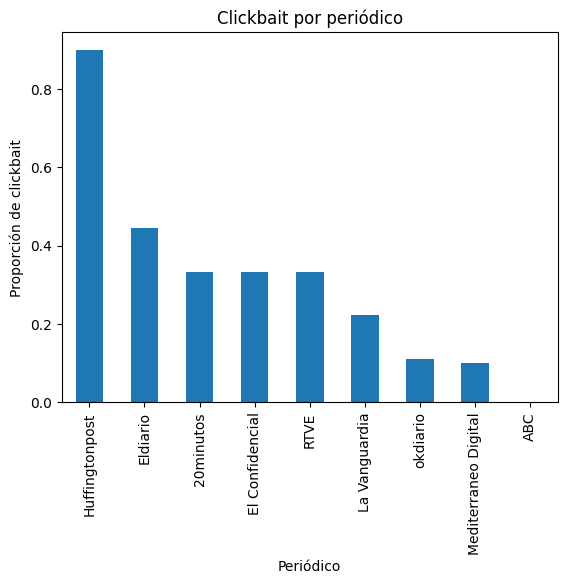

In [189]:
import matplotlib.pyplot as plt

summary["ratio"].plot(kind="bar")
plt.ylabel("Proporción de clickbait")
plt.title("Clickbait por periódico")
plt.show()

In [190]:
df["len_titulo"] = df["Título"].str.len()
df.groupby("cb")["len_titulo"].describe()

,count,mean,std,min,25%,50%,75%,max
cb,,,,,,,,
False,57.0,85.929825,21.712291,31.0,72.00,85.0,103.00,153.0
True,26.0,87.038462,33.903959,4.0,61.75,89.5,107.75,139.0


# Pruebas de métricas

## Longitud del texto


=== LONGITUD EN PALABRAS ===
       count        mean         std    min     25%    50%     75%     max
cb                                                                        
False   57.0  537.543860  605.943629   48.0  292.00  381.0  628.00  4330.0
True    26.0  596.423077  407.656441  140.0  327.75  409.5  866.25  1505.0

=== LONGITUD EN CARACTERES ===
       count         mean          std    min      25%     50%      75%  \
cb                                                                        
False   57.0  3223.403509  3509.388601  267.0  1666.00  2356.0  3617.00   
True    26.0  3546.653846  2444.935646  765.0  1924.75  2518.5  5083.75   

           max  
cb              
False  24767.0  
True    9570.0  

=== TEST LONGITUD PALABRAS ===
Statistic: 865.5
p-value: 0.22343336014486914

=== TEST LONGITUD CARACTERES ===
Statistic: 844.0
p-value: 0.3142453504095969


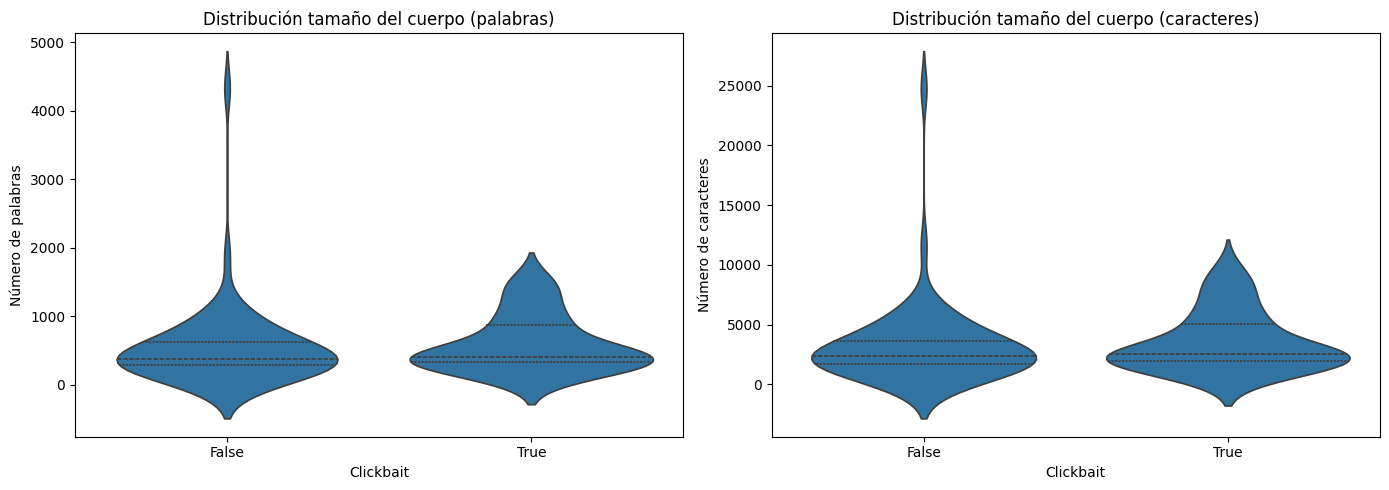

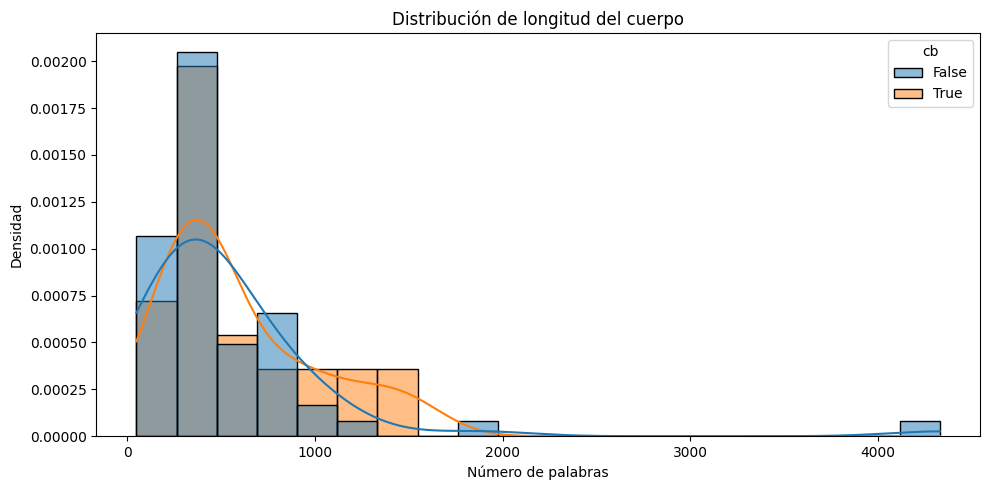

In [191]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu


# ============================================================
# TAMAÑO DEL CUERPO
# ============================================================

# número de palabras
df["body_length_words"] = df["Contenido"].apply(
    lambda x: len(str(x).split())
)

# número de caracteres
df["body_length_chars"] = df["Contenido"].apply(
    lambda x: len(str(x))
)


# ============================================================
# RESUMEN ESTADÍSTICO
# ============================================================

print("\n=== LONGITUD EN PALABRAS ===")
print(
    df.groupby("cb")["body_length_words"].describe()
)

print("\n=== LONGITUD EN CARACTERES ===")
print(
    df.groupby("cb")["body_length_chars"].describe()
)


# ============================================================
# TEST ESTADÍSTICO
# ============================================================

click_words = df[df["cb"] == True]["body_length_words"]
noclick_words = df[df["cb"] == False]["body_length_words"]

stat_words, p_words = mannwhitneyu(click_words, noclick_words)

print("\n=== TEST LONGITUD PALABRAS ===")
print("Statistic:", stat_words)
print("p-value:", p_words)


click_chars = df[df["cb"] == True]["body_length_chars"]
noclick_chars = df[df["cb"] == False]["body_length_chars"]

stat_chars, p_chars = mannwhitneyu(click_chars, noclick_chars)

print("\n=== TEST LONGITUD CARACTERES ===")
print("Statistic:", stat_chars)
print("p-value:", p_chars)


# ============================================================
# VIOLIN PLOT
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.violinplot(
    data=df,
    x="cb",
    y="body_length_words",
    inner="quartile",
    ax=axes[0]
)

axes[0].set_title("Distribución tamaño del cuerpo (palabras)")
axes[0].set_xlabel("Clickbait")
axes[0].set_ylabel("Número de palabras")


sns.violinplot(
    data=df,
    x="cb",
    y="body_length_chars",
    inner="quartile",
    ax=axes[1]
)

axes[1].set_title("Distribución tamaño del cuerpo (caracteres)")
axes[1].set_xlabel("Clickbait")
axes[1].set_ylabel("Número de caracteres")


plt.tight_layout()
plt.show()


# ============================================================
# HISTOGRAMA SUPERPUESTO
# ============================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="body_length_words",
    hue="cb",
    kde=True,
    bins=20,
    stat="density",
    common_norm=False,
    alpha=0.5
)

plt.title("Distribución de longitud del cuerpo")
plt.xlabel("Número de palabras")
plt.ylabel("Densidad")

plt.tight_layout()
plt.show()

## Prueba de legibilidad de Flesch-Kincaid

https://es.wikipedia.org/wiki/Prueba_de_legibilidad_de_Flesch-Kincaid

No hay evidencia estadística de que el clickbait y el no-clickbait difieran en complejidad lingüística medida por legibilidad del contenido. Con el título hay mayor diferencia

la señal de diferencia entre clickbait y no-clickbait aparece débilmente, y depende de la métrica usada.

El clickbait en titulares presenta diferencias estadísticamente significativas en métricas de complejidad lexical sensibles (SMOG, Gunning Fog), pero no en métricas globales de legibilidad (Flesch), lo que sugiere que la variación se concentra en cambios locales de densidad léxica más que en estructura sintáctica global.

In [192]:
import spacy
import syllapy
import numpy as np



def contar_silabas(texto):
    palabras = [w for w in texto.split() if w.isalpha()]
    return sum(syllapy.count(w.lower()) for w in palabras)


def flesch_es(texto):
    doc = nlp(texto)

    oraciones = list(doc.sents)
    palabras = [t.text for t in doc if t.is_alpha]

    n_oraciones = max(len(oraciones), 1)
    n_palabras = max(len(palabras), 1)
    n_silabas = contar_silabas(texto)

    score = 206.84 - 0.60*(n_silabas/n_palabras) - 1.02*(n_palabras/n_oraciones)
    return score

df["flesch"] = df["Contenido"].apply(flesch_es)

resumen = df.groupby("Periódico")["flesch"].agg(["mean", "std", "count"]).sort_values("mean")
print(resumen)

                            mean        std  count
Periódico                                         
Mediterraneo Digital  104.078172  32.147374     10
20minutos             112.759071  80.594993      9
ABC                   136.748010  85.103843      9
El Confidencial       159.557007  37.009432      9
Huffingtonpost        159.915141  17.827525     10
La Vanguardia         165.723621  10.784912      9
Eldiario              166.597533  13.907946      9
RTVE                  174.309214   9.043136      9
okdiario              181.796766   6.688694      9


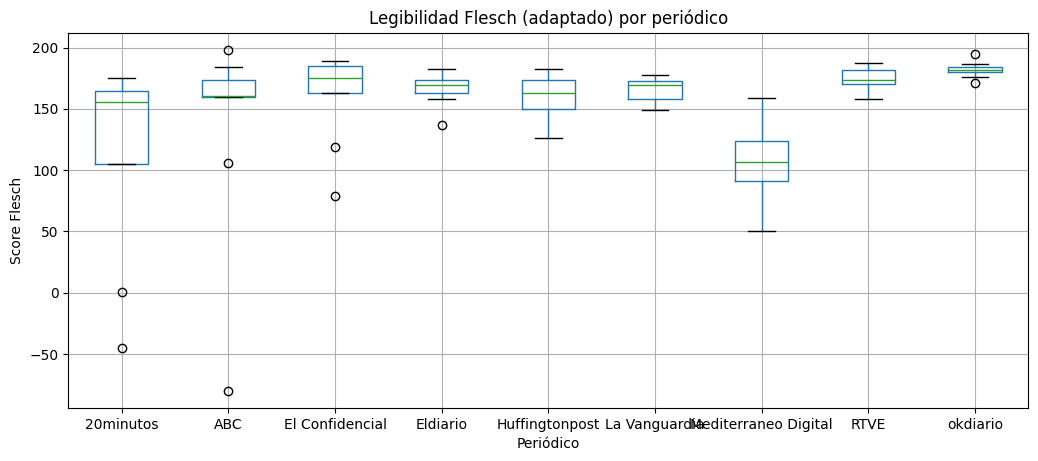

In [193]:
df.boxplot(column="flesch", by="Periódico", figsize=(12,5))
plt.title("Legibilidad Flesch (adaptado) por periódico")
plt.suptitle("")
plt.ylabel("Score Flesch")
plt.show()

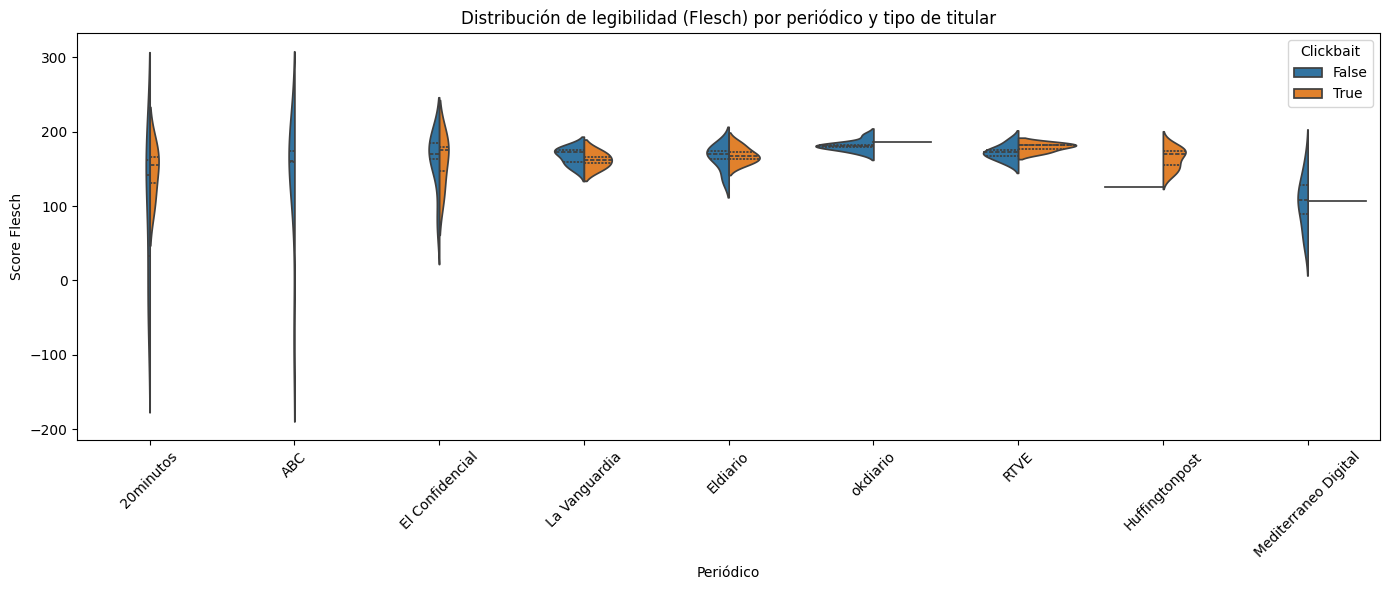

In [194]:

plt.figure(figsize=(14,6))

sns.violinplot(
    data=df,
    x="Periódico",
    y="flesch",
    hue="cb",
    split=True,   # divide clickbait vs no clickbait dentro del mismo violín
    inner="quartile"
)

plt.title("Distribución de legibilidad (Flesch) por periódico y tipo de titular")
plt.xlabel("Periódico")
plt.ylabel("Score Flesch")
plt.xticks(rotation=45)
plt.legend(title="Clickbait")
plt.tight_layout()
plt.show()

In [195]:
clickbait = df[df["cb"] == True]["flesch"].dropna()
noclickbait = df[df["cb"] == False]["flesch"].dropna()

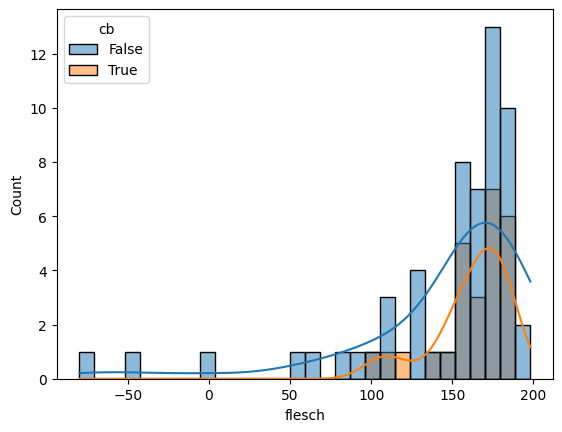

In [196]:
sns.histplot(data=df, x="flesch", hue="cb", kde=True, bins=30)
plt.show()

In [197]:
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(clickbait, noclickbait)

print("Statistic:", stat)
print("p-value:", p)

Statistic: 796.0
p-value: 0.592590567370329


## Índice de Gunning Fog

In [198]:
import spacy
import syllapy

def gunning_fog(texto):
    doc = nlp(texto)

    palabras = [t.text for t in doc if t.is_alpha]
    oraciones = list(doc.sents)

    n_palabras = len(palabras)
    n_oraciones = max(len(oraciones), 1)

    complejas = sum(1 for w in palabras if syllapy.count(w.lower()) >= 3)

    fog = 0.4 * ((n_palabras / n_oraciones) + 100 * (complejas / n_palabras))
    return fog

df["fog"] = df["Contenido"].apply(gunning_fog)

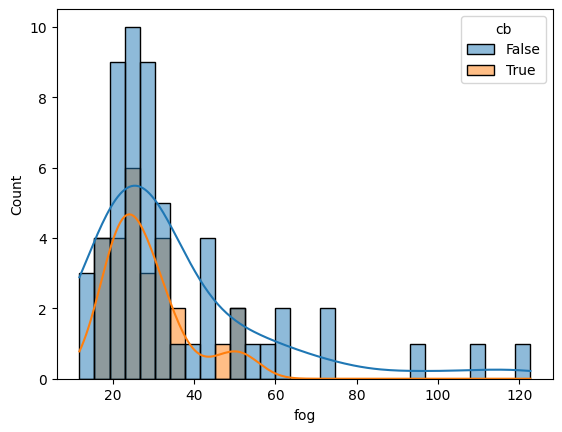

In [199]:
sns.histplot(data=df, x="fog", hue="cb", kde=True, bins=30)
plt.show()

In [200]:
click = df[df["cb"] == True]["fog"]
no_click = df[df["cb"] == False]["fog"]

mannwhitneyu(click, no_click)

MannwhitneyuResult(statistic=np.float64(633.0), pvalue=np.float64(0.2912221450174558))

## Índice de SMOG

In [201]:
import numpy as np

def smog(texto):
    doc = nlp(texto)

    palabras = [t.text for t in doc if t.is_alpha]
    oraciones = list(doc.sents)

    if len(oraciones) == 0:
        return np.nan

    complejas = sum(1 for w in palabras if syllapy.count(w.lower()) >= 3)

    return 1.043 * np.sqrt(complejas * (30 / len(oraciones))) + 3.1291

df["smog"] = df["Título"].apply(smog)

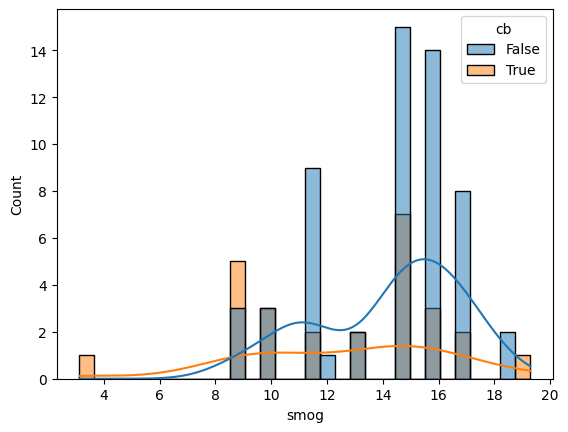

In [202]:
sns.histplot(data=df, x="smog", hue="cb", kde=True, bins=30)
plt.show()

In [203]:
click = df[df["cb"] == True]["smog"]
no_click = df[df["cb"] == False]["smog"]

mannwhitneyu(click, no_click)

MannwhitneyuResult(statistic=np.float64(533.5), pvalue=np.float64(0.03880430335894829))

## Entropía de Shannon


=== ENTROPÍA CONTENIDO ===
       count      mean       std       min       25%       50%       75%  \
cb                                                                         
False   57.0  6.880048  0.648680  5.150324  6.529281  6.888308  7.272740   
True    26.0  7.162330  0.513852  6.182703  6.924926  7.079993  7.564167   

            max  
cb               
False  8.440045  
True   8.151356  

=== ENTROPÍA CONTENIDO NORMALIZADA ===
       count      mean       std       min       25%       50%       75%  \
cb                                                                         
False   57.0  0.903516  0.027627  0.823015  0.886218  0.901472  0.918514   
True    26.0  0.901650  0.028578  0.846087  0.888900  0.902409  0.924673   

            max  
cb               
False  0.981402  
True   0.950046  

=== ENTROPÍA TÍTULO ===
       count      mean       std       min       25%       50%       75%  \
cb                                                                         
F

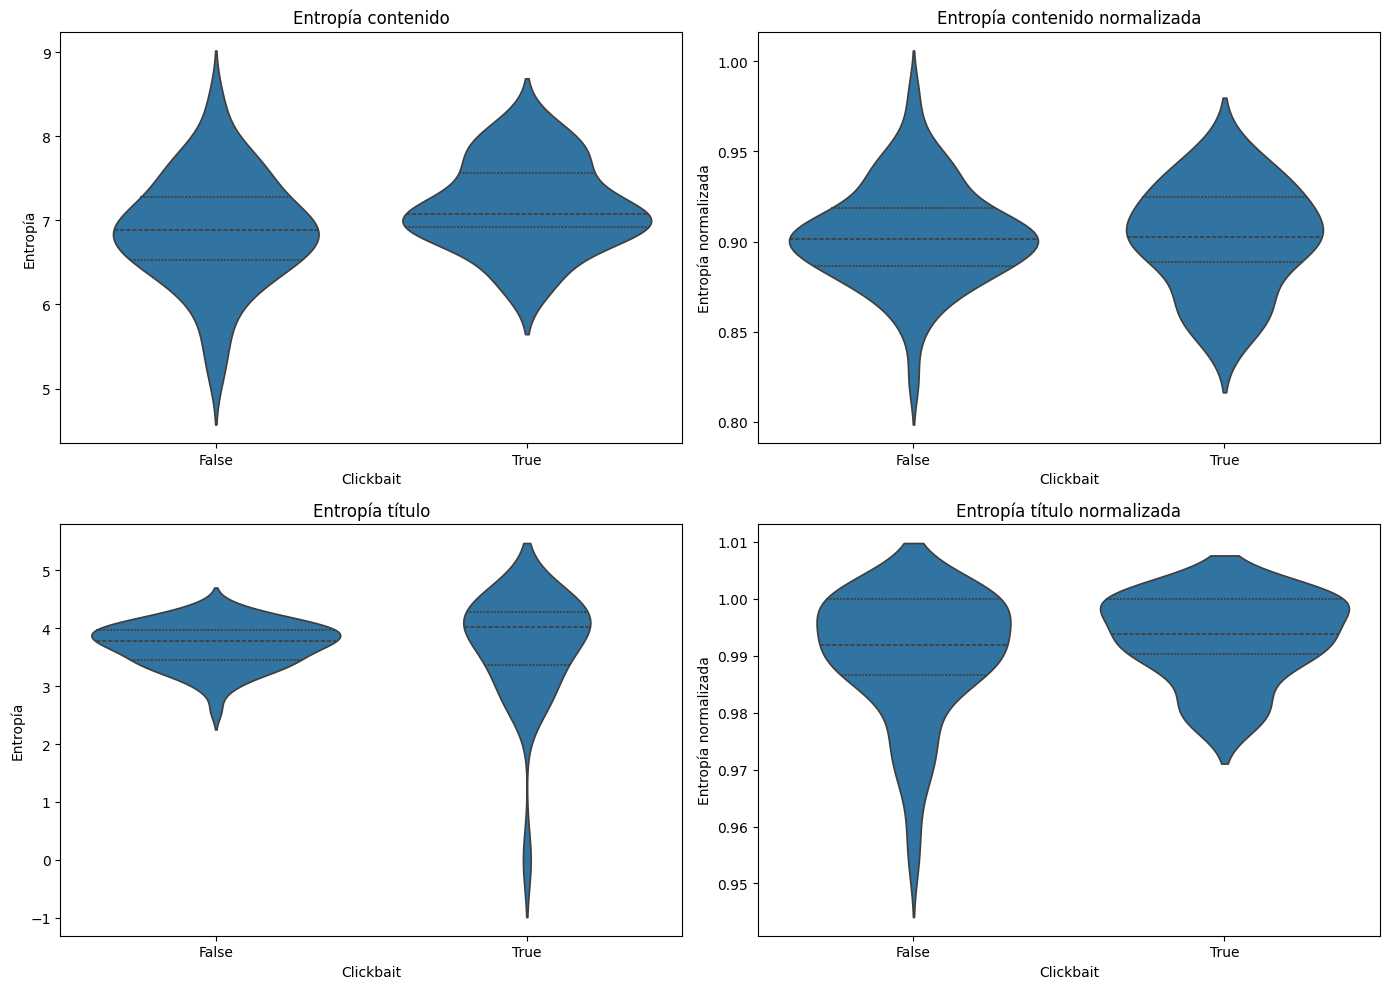

In [204]:
import numpy as np
import pandas as pd
import re

from collections import Counter
from scipy.stats import mannwhitneyu

import seaborn as sns
import matplotlib.pyplot as plt


# ============================================================
# LIMPIEZA DE TEXTO
# ============================================================

def limpiar_texto(texto):

    if not isinstance(texto, str):
        return ""

    texto = texto.lower()

    # eliminar urls
    texto = re.sub(r"http\S+", "", texto)

    # dejar solo letras y espacios
    texto = re.sub(r"[^a-záéíóúñü\s]", " ", texto)

    # eliminar espacios múltiples
    texto = re.sub(r"\s+", " ", texto).strip()

    return texto


# ============================================================
# ENTROPÍA DE SHANNON
# ============================================================

def shannon_entropy(texto):

    texto = limpiar_texto(texto)

    palabras = texto.split()

    if len(palabras) == 0:
        return np.nan

    freqs = Counter(palabras)

    probs = np.array(list(freqs.values())) / len(palabras)

    entropy = -np.sum(probs * np.log2(probs))

    return entropy


# ============================================================
# ENTROPÍA NORMALIZADA
# ============================================================

def normalized_entropy(texto):

    texto = limpiar_texto(texto)

    palabras = texto.split()

    if len(palabras) < 2:
        return np.nan

    freqs = Counter(palabras)

    probs = np.array(list(freqs.values())) / len(palabras)

    H = -np.sum(probs * np.log2(probs))

    Hmax = np.log2(len(freqs))

    if Hmax == 0:
        return 0

    return H / Hmax


# ============================================================
# CALCULAR ENTROPÍAS
# ============================================================

# contenido
df["entropy_content"] = df["Contenido"].apply(shannon_entropy)

# contenido normalizado
df["entropy_content_norm"] = df["Contenido"].apply(normalized_entropy)

# títulos
df["entropy_title"] = df["Título"].apply(shannon_entropy)

# títulos normalizados
df["entropy_title_norm"] = df["Título"].apply(normalized_entropy)


# ============================================================
# RESUMEN ESTADÍSTICO
# ============================================================

print("\n=== ENTROPÍA CONTENIDO ===")
print(df.groupby("cb")["entropy_content"].describe())

print("\n=== ENTROPÍA CONTENIDO NORMALIZADA ===")
print(df.groupby("cb")["entropy_content_norm"].describe())

print("\n=== ENTROPÍA TÍTULO ===")
print(df.groupby("cb")["entropy_title"].describe())

print("\n=== ENTROPÍA TÍTULO NORMALIZADA ===")
print(df.groupby("cb")["entropy_title_norm"].describe())


# ============================================================
# TEST MANN-WHITNEY
# ============================================================

def mannwhitney_test(columna):

    click = df[df["cb"] == True][columna].dropna()
    noclick = df[df["cb"] == False][columna].dropna()

    stat, p = mannwhitneyu(click, noclick)

    print(f"\n--- {columna} ---")
    print("Statistic:", stat)
    print("p-value:", p)


mannwhitney_test("entropy_content")
mannwhitney_test("entropy_content_norm")
mannwhitney_test("entropy_title")
mannwhitney_test("entropy_title_norm")


# ============================================================
# VIOLIN PLOTS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.violinplot(
    data=df,
    x="cb",
    y="entropy_content",
    inner="quartile",
    ax=axes[0,0]
)

axes[0,0].set_title("Entropía contenido")
axes[0,0].set_xlabel("Clickbait")
axes[0,0].set_ylabel("Entropía")


sns.violinplot(
    data=df,
    x="cb",
    y="entropy_content_norm",
    inner="quartile",
    ax=axes[0,1]
)

axes[0,1].set_title("Entropía contenido normalizada")
axes[0,1].set_xlabel("Clickbait")
axes[0,1].set_ylabel("Entropía normalizada")


sns.violinplot(
    data=df,
    x="cb",
    y="entropy_title",
    inner="quartile",
    ax=axes[1,0]
)

axes[1,0].set_title("Entropía título")
axes[1,0].set_xlabel("Clickbait")
axes[1,0].set_ylabel("Entropía")


sns.violinplot(
    data=df,
    x="cb",
    y="entropy_title_norm",
    inner="quartile",
    ax=axes[1,1]
)

axes[1,1].set_title("Entropía título normalizada")
axes[1,1].set_xlabel("Clickbait")
axes[1,1].set_ylabel("Entropía normalizada")


plt.tight_layout()
plt.show()

## LSA

In [205]:
# corpus=cargar_datos(1)
similitudes,tfidf_lsa=LSA_vectors(corpus,min_df=2)


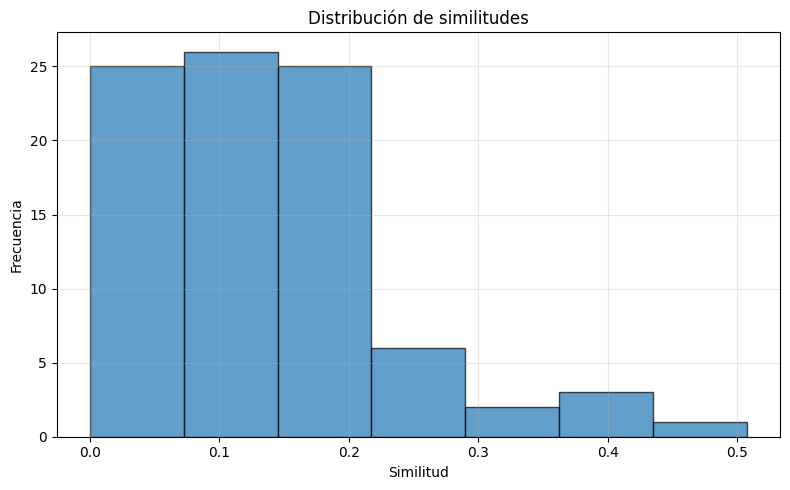

In [206]:
plt.figure(figsize=(8, 5))

plt.hist(
    similitudes,
    bins=7,          # Número de bins
    edgecolor='black',
    alpha=0.7
)

plt.xlabel("Similitud")
plt.ylabel("Frecuencia")
plt.title("Distribución de similitudes")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Embeding semántico

Aplicar:Crear un vector adicional de features de decticos, puntuación, superlativos. Si el embeding cae en una zona del espacio muy cargada de adjetivos pero el cuerpo está en una zona neutral, esa diferencia puede ser indicios de clickbait.

Título: casi el 70% de la juventud española no está satisfecha con la democracia y más de la mitad cree que hace falta mano dura


Fragmentos:
  Fragmento 1: el 68% de la juventud española declara poca o ninguna satisfacción con el funcionamiento de
  Fragmento 2: la democracia. esta es una de las principales conclusiones del informe jóvenes españoles 2026 que
  Fragmento 3: este martes ha presentado la fundación sm y que apunta a un desplazamiento hacia valores
  Fragmento 4: más individualistas y hedonistas junto a una clara disminución de los valores idealistas como el
  Fragmento 5: compromiso con el medio ambiente la igualdad social o de género. según el estudio realizado
  Fragmento 6: en la primavera del año pasado a partir de casi 1.700 entrevistas con jóvenes de
  Fragmento 7: 15 a 29 años la espiritualidad gana terreno en la vida de los jóvenes para
  Fragmento 8: el 38% es importante o muy importante la religión el nivel más alto desde que
  Fragmento 9: comenzó a realizarse

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Batches: 100%|██████████| 3/3 [00:00<00:00, 11.87it/s]
/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


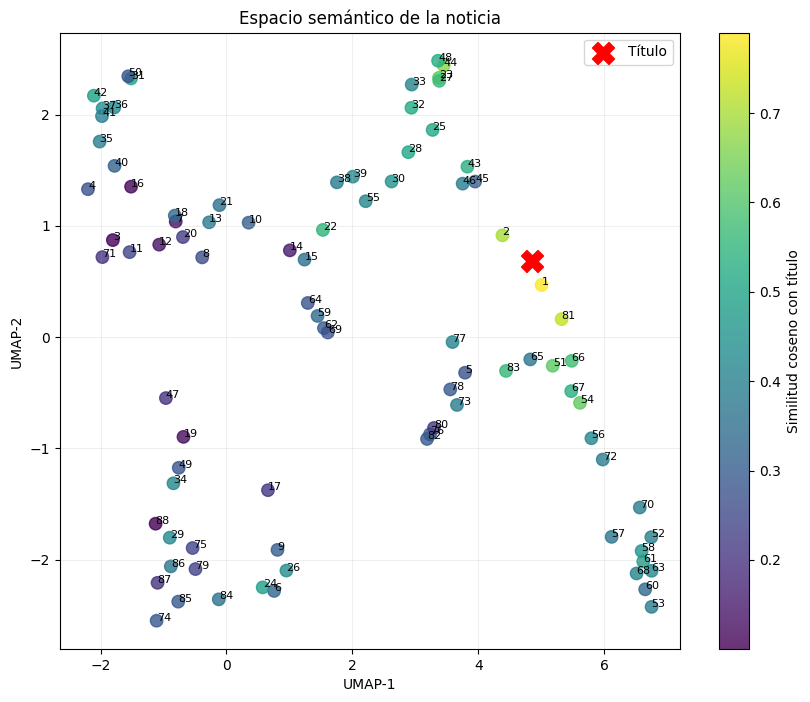

In [208]:
# corpus=cargar_datos(1)
titulo, fragmentos_contenido,noticia=cargar_datos(noticias, n_noticia=5, print_info=True)
corpus = [titulo] + fragmentos_contenido

similarities,embeddings=embedding_sentence_transformers(corpus,embedding_model)
embedding_2d=embedding_umap(similarities,embeddings, plot=True)

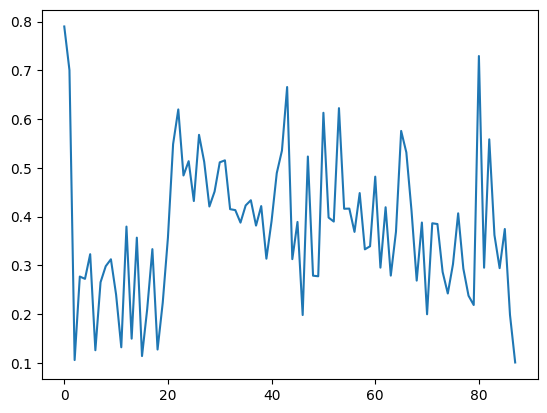

In [209]:
plt.plot(similarities)

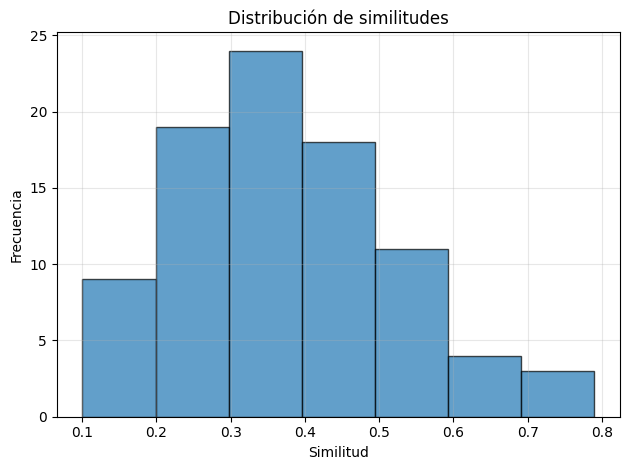

In [210]:
plt.hist(
    similarities,
    bins=7,          # Número de bins
    edgecolor='black',
    alpha=0.7
)

plt.xlabel("Similitud")
plt.ylabel("Frecuencia")
plt.title("Distribución de similitudes")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Embeding semántico + Features lingüísticos

Se ha decidido añadir un feature lingüístico con el objetivo de comparar el lenguaje emotivo/directo entre el título y el cuerpo de la noticia. Estos features capturan ese patrón: títulos con muchos deícticos y puntuación atraen pero el contenido es neutral.
Contadores de deícticos (yo, tú, él...), puntuación (!, ?, ¡¿) y superlativos (muy, increíblemente, -ísimo).

- Para que se puedan comparar el deícticos, puntuación y los superlativos se ha decidido normalizar con StandardScaler

- Se calcula el score como:
$$score=(1-similitud)\cdot diferencia_lingüística$$
De tal forma que si la similitud es 1 en el espacio embebido será 0.
Cuánto más sea la diferencia entre el título y el contenido mayor será el diferencia_lingüística.

De tal forma que solo será alto si ambas condiciones ocurren.

Batches: 100%|██████████| 3/3 [00:00<00:00, 11.85it/s]
/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


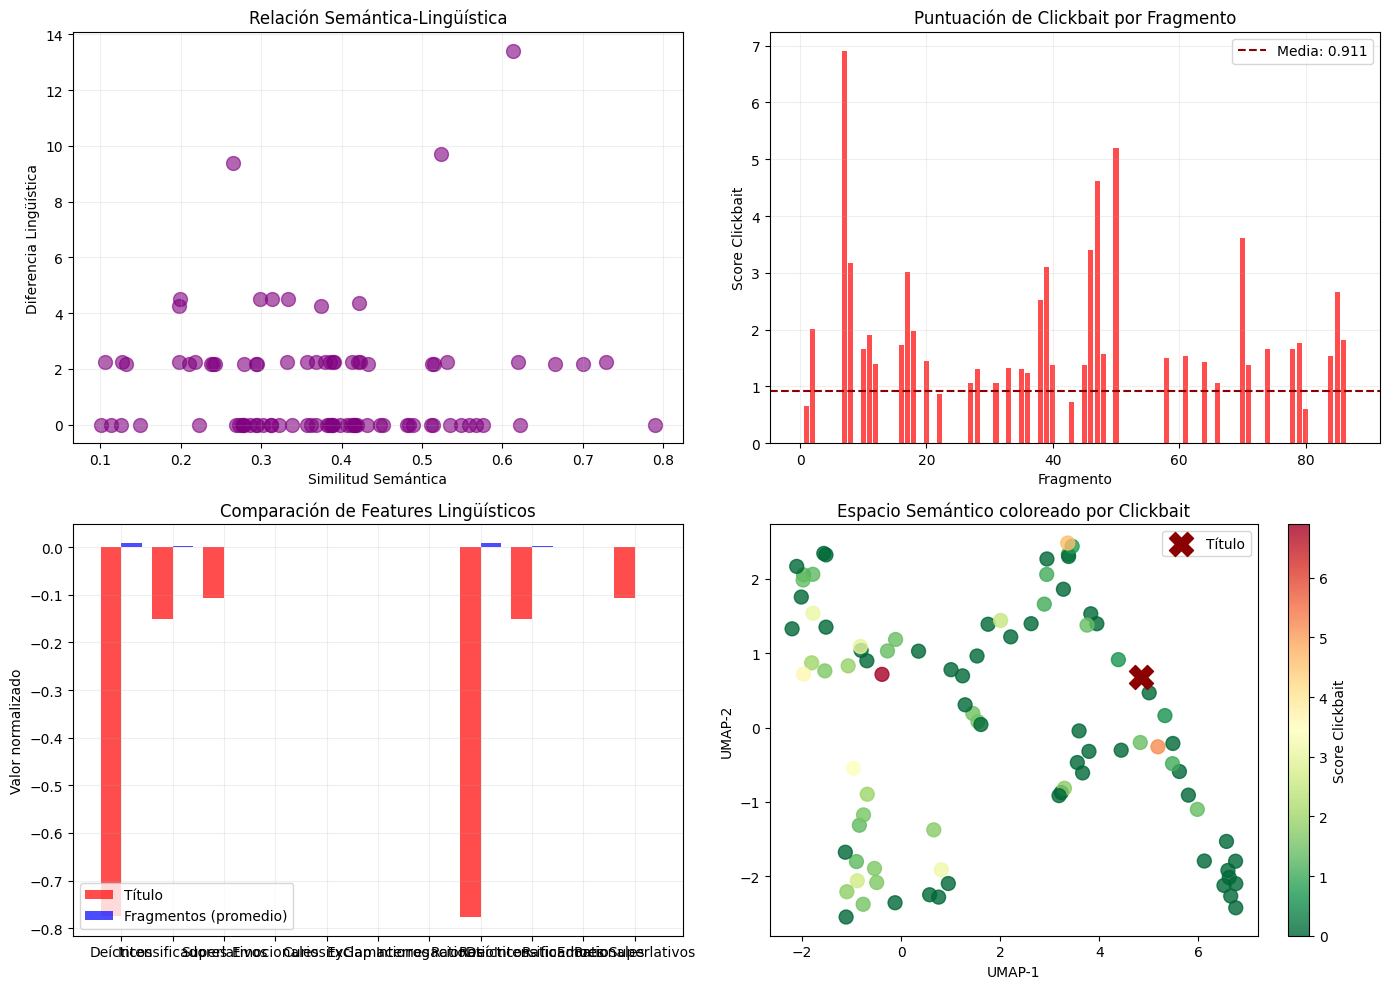

In [211]:
def analizar_clickbait(noticias, n_noticia, embedding_model, plot=False):
    """
    Combina embeddings semánticos con features lingüísticos para detectar clickbait
    input: noticias (list), n_noticia (int), plot (bool)
    output: score_medio (float), análisis (dict)
    """
    # 1. Cargar datos
    
    titulo, fragmentos, noticia = cargar_datos(noticias, n_noticia)
    periodico=noticia["Periódico"]
    categoria=noticia["Categoría"]
    link=noticia["Link"]
    clickbait=noticia["cb"]
    corpus = [titulo] + fragmentos
    
    # 2. Extraer features lingüísticos
    features_ling = extraer_features_linguisticos(corpus)
    diferencias_ling, (titulo_norm, fragmentos_norm) = calcular_diferencia_features(corpus)
    
    # 3. Embeddings semánticos
    similarities, embeddings = embedding_sentence_transformers(corpus,embedding_model)
    embedding_2d = embedding_umap(similarities, embeddings, plot=False)
    # 3.1 Information structure features ---------------------------------- NUEVO
    similarities_array = np.array(similarities)

    # posición del máximo (relevancia tardía)
    argmax_relevance = np.argmax(similarities_array)

    # normalizado (0 = inicio, 1 = final)
    position_relevance = argmax_relevance / (len(similarities_array) - 1 + 1e-8)

    # information delay (qué tan tarde aparece la info relevante)
    information_delay = position_relevance 
    split = len(similarities_array) // 2

    early_mean = np.mean(similarities_array[:split])
    late_mean = np.mean(similarities_array[split:])

    early_late_ratio = early_mean / (late_mean + 1e-8)
    #------------------------------------------------------------------------------ NUEVO
    # 4. Normalizar features lingüísticos
    scaler = StandardScaler()
    features_norm = scaler.fit_transform(features_ling)
    titulo_features = features_norm[0]
    fragmentos_features = features_norm[1:]
    
    # 5. Distancia en espacio UMAP
    titulo_2d = embedding_2d[0]
    fragmentos_2d = embedding_2d[1:]
    dist_semantica = np.linalg.norm(fragmentos_2d - titulo_2d, axis=1)
    
    # 6. SCORE CLICKBAIT: (1 - similitud semántica) × distancia lingüística
    score_clickbait = (1 - similarities) * diferencias_ling
    score_medio = np.mean(score_clickbait)
    
    analisis = {
        'titulo': titulo,
        'periodico': periodico,
        'categoria': categoria,
        'link': link,
        'score_clickbait': score_clickbait,
        'score_medio': score_medio,
        'similitud_semantica': similarities,
        'diferencias_linguisticas': diferencias_ling,
        'dist_semantica': dist_semantica,
        'features_titulo': titulo_features,
        'features_fragmentos': fragmentos_features,
        'information_delay': information_delay,
        'position_relevance': position_relevance,
        'early_late_ratio': early_late_ratio,
        'argmax_relevance': argmax_relevance,
    }
    
    if plot:
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        
        # Similitud semántica vs distancia lingüística
        axes[0, 0].scatter(similarities, diferencias_ling, s=100, alpha=0.6, color='purple')
        axes[0, 0].set_xlabel('Similitud Semántica')
        axes[0, 0].set_ylabel('Diferencia Lingüística')
        axes[0, 0].set_title('Relación Semántica-Lingüística')
        axes[0, 0].grid(alpha=0.2)
        
        # Score de clickbait por fragmento
        axes[0, 1].bar(range(len(score_clickbait)), score_clickbait, color='red', alpha=0.7)
        axes[0, 1].axhline(y=score_medio, color='darkred', linestyle='--', label=f'Media: {score_medio:.3f}')
        axes[0, 1].set_xlabel('Fragmento')
        axes[0, 1].set_ylabel('Score Clickbait')
        axes[0, 1].set_title('Puntuación de Clickbait por Fragmento')
        axes[0, 1].legend()
        axes[0, 1].grid(alpha=0.2)
        
        # Features: título vs fragmentos
        features_names = [
            'Deícticos',
            'Intensificadores',
            'Superlativos',
            'Emocionales',
            'CuriosityGap',
            'Exclamaciones',
            'Interrogaciones',
            #'PuntosSuspensivos',
            #'Mayúsculas',
            #'Números',
            'RatioDeícticos',
            'RatioIntensificadores',
            'RatioEmocionales',
            'RatioSuperlativos'
        ]
        x_pos = np.arange(len(features_names))
        titulo_vals = titulo_features
        fragmentos_vals = np.mean(fragmentos_features, axis=0)
        
        axes[1, 0].bar(x_pos - 0.2, titulo_vals, 0.4, label='Título', color='red', alpha=0.7)
        axes[1, 0].bar(x_pos + 0.2, fragmentos_vals, 0.4, label='Fragmentos (promedio)', color='blue', alpha=0.7)
        axes[1, 0].set_ylabel('Valor normalizado')
        axes[1, 0].set_title('Comparación de Features Lingüísticos')
        axes[1, 0].set_xticks(x_pos)
        axes[1, 0].set_xticklabels(features_names)
        axes[1, 0].legend()
        axes[1, 0].grid(alpha=0.2)
        
        # Espacio UMAP coloreado por score clickbait
        x = embedding_2d[:, 0]
        y = embedding_2d[:, 1]
        scatter = axes[1, 1].scatter(x[1:], y[1:], c=score_clickbait, cmap='RdYlGn_r', s=100, alpha=0.8)
        axes[1, 1].scatter(x[0], y[0], color='darkred', s=300, marker='X', label='Título')
        axes[1, 1].set_xlabel('UMAP-1')
        axes[1, 1].set_ylabel('UMAP-2')
        axes[1, 1].set_title('Espacio Semántico coloreado por Clickbait')
        axes[1, 1].legend()
        plt.colorbar(scatter, ax=axes[1, 1], label='Score Clickbait')
        
        plt.tight_layout()
        plt.show()
    
    return score_medio, analisis

score, datos = analizar_clickbait(noticias, 5, embedding_model, plot=True)

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches: 100%|██████████| 2/2 [00:00<00:00, 12.36it/s]
/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✓ Noticia 0/82


Batches: 100%|██████████| 1/1 [00:00<00:00, 21.87it/s]
/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✓ Noticia 1/82


...

✓ Noticia 80/82


Batches: 100%|██████████| 1/1 [00:00<00:00, 26.91it/s]

✓ Noticia 81/82



/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
Batches: 100%|██████████| 2/2 [00:00<00:00, 25.71it/s]
/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✓ Noticia 82/82

ESTADÍSTICAS DE CLICKBAIT

📊 GENERAL:
  • Total noticias: 83
  • Score medio: 1.084
  • Score máximo: 3.488
  • Score mínimo: 0.000
  • Desviación estándar: 0.526

🏆 NOTICIAS CON MAYOR CLICKBAIT:
  79. [internacional] trump toda una civilización morirá esta noche... (3.488)
  46. [Internacional] lo que acaban de ver en china da miedo y el mundo tiembla av... (3.201)
  54. [Internacional] ¿ha perdido trump apoyos por la guerra de irán? por qué y có... (2.546)
  40. [Nacional] el pnv amenaza con retirar su apoyo a sánchez si no cuida la... (2.187)
  55. [Internacional] el cierre de filas frente a israel se estrecha en parte de e... (1.915)

📁 POR CATEGORÍA:
  • Internacional: 21 noticias, media=1.249
  • Nacional: 21 noticias, media=0.974
  • Cultura: 21 noticias, media=0.981
  • virales: 10 noticias, media=1.115
  • internacional: 10 noticias, media=1.150

📰 POR PERIÓDICO:
  • 20minutos: 9 noticias, media=1.077
  • ABC: 9 noticias, media=0.762
  • El Confidencial: 9 not

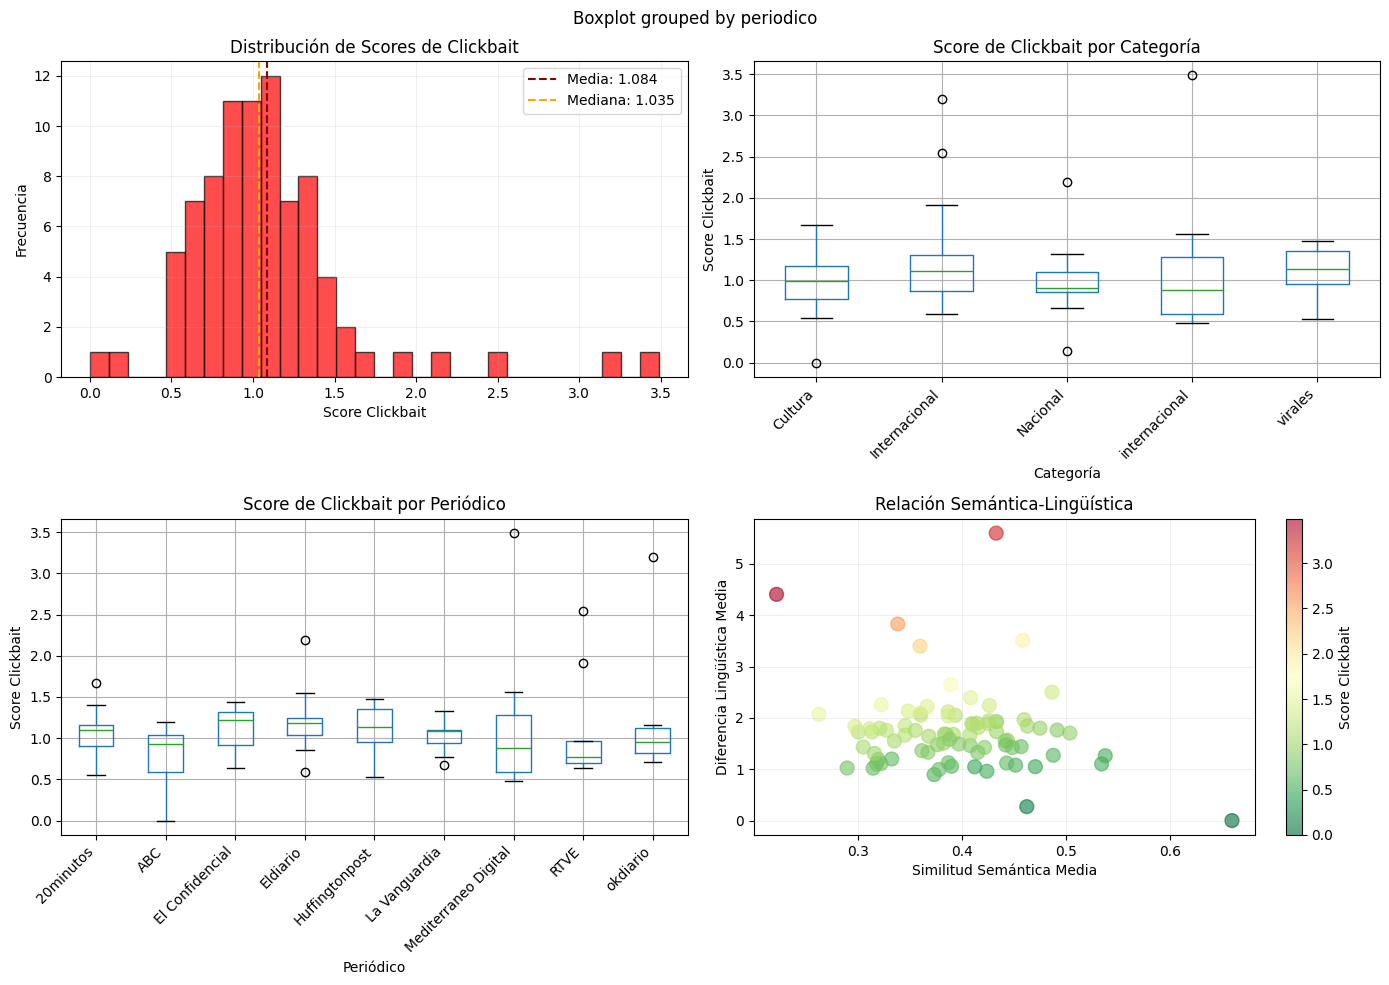

In [215]:
# ESTE CÓDIGO NO ESTÁ BIEN MIRADO, SOLO ERAP ARA SACAR RESULTADOS RÁPIDOS DE LO ANTERIOR


def procesar_todas_noticias(noticias):
    """
    Procesa todas las noticias y calcula score de clickbait
    input: noticias (list)
    output: dataframe con scores y metadatos
    """
    resultados = []
    
    for n in range(len(noticias)):
        try:
            score_medio, analisis = analizar_clickbait(noticias, n, embedding_model, plot=False)
            
            noticia = noticias[n]
            resultados.append({
                'id_noticia': n,
                'titulo': noticia.get('Título', ''),
                'categoria': noticia.get('Categoría', ''),
                'periodico': noticia.get('Periódico', ''),
                'clickbait': noticia.get('cb', False),
                'score_clickbait': score_medio,
                'similitud_media': np.mean(analisis['similitud_semantica']),
                'diferencia_ling_media': np.mean(analisis['diferencias_linguisticas']),
                'deicticos_titulo': analisis['features_titulo'][0],
                'puntuacion_titulo': analisis['features_titulo'][1],
                'superlativos_titulo': analisis['features_titulo'][2],
                'information_delay': analisis['information_delay'],
                'position_relevance': analisis['position_relevance'],
                'early_late_ratio': analisis['early_late_ratio'],
                'argmax_relevance': analisis['argmax_relevance'],

            })
            
            print(f"✓ Noticia {n}/{len(noticias)-1}")
        
        except Exception as e:
            print(f"✗ Error en noticia {n}: {e}")
    
    df = pd.DataFrame(resultados)
    return df


def visualizar_resultados_clickbait(df):
    """
    Visualiza histogramas y estadísticas de clickbait
    input: df (pandas DataFrame)
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Histograma de scores
    axes[0, 0].hist(df['score_clickbait'], bins=30, color='red', alpha=0.7, edgecolor='black')
    axes[0, 0].axvline(df['score_clickbait'].mean(), color='darkred', linestyle='--', 
                       label=f'Media: {df["score_clickbait"].mean():.3f}')
    axes[0, 0].axvline(df['score_clickbait'].median(), color='orange', linestyle='--', 
                       label=f'Mediana: {df["score_clickbait"].median():.3f}')
    axes[0, 0].set_xlabel('Score Clickbait')
    axes[0, 0].set_ylabel('Frecuencia')
    axes[0, 0].set_title('Distribución de Scores de Clickbait')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.2)
    
    # 2. Score por categoría
    df.boxplot(column='score_clickbait', by='categoria', ax=axes[0, 1])
    axes[0, 1].set_title('Score de Clickbait por Categoría')
    axes[0, 1].set_xlabel('Categoría')
    axes[0, 1].set_ylabel('Score Clickbait')
    plt.sca(axes[0, 1])
    plt.xticks(rotation=45, ha='right')
    
    # 3. Score por periódico
    df.boxplot(column='score_clickbait', by='periodico', ax=axes[1, 0])
    axes[1, 0].set_title('Score de Clickbait por Periódico')
    axes[1, 0].set_xlabel('Periódico')
    axes[1, 0].set_ylabel('Score Clickbait')
    plt.sca(axes[1, 0])
    plt.xticks(rotation=45, ha='right')
    
    # 4. Scatter: similitud vs diferencia lingüística
    scatter = axes[1, 1].scatter(df['similitud_media'], df['diferencia_ling_media'], 
                                c=df['score_clickbait'], cmap='RdYlGn_r', s=100, alpha=0.6)
    axes[1, 1].set_xlabel('Similitud Semántica Media')
    axes[1, 1].set_ylabel('Diferencia Lingüística Media')
    axes[1, 1].set_title('Relación Semántica-Lingüística')
    plt.colorbar(scatter, ax=axes[1, 1], label='Score Clickbait')
    axes[1, 1].grid(alpha=0.2)
    
    plt.tight_layout()
    plt.show()


def estadisticas_clickbait(df):
    """
    Imprime estadísticas generales
    input: df (pandas DataFrame)
    """
    print("\n" + "="*80)
    print("ESTADÍSTICAS DE CLICKBAIT")
    print("="*80)
    
    print(f"\n📊 GENERAL:")
    print(f"  • Total noticias: {len(df)}")
    print(f"  • Score medio: {df['score_clickbait'].mean():.3f}")
    print(f"  • Score máximo: {df['score_clickbait'].max():.3f}")
    print(f"  • Score mínimo: {df['score_clickbait'].min():.3f}")
    print(f"  • Desviación estándar: {df['score_clickbait'].std():.3f}")
    
    print(f"\n🏆 NOTICIAS CON MAYOR CLICKBAIT:")
    top_5 = df.nlargest(5, 'score_clickbait')[['id_noticia', 'titulo', 'categoria', 'score_clickbait']]
    for idx, row in top_5.iterrows():
        print(f"  {row['id_noticia']}. [{row['categoria']}] {row['titulo'][:60]}... ({row['score_clickbait']:.3f})")
    
    print(f"\n📁 POR CATEGORÍA:")
    for cat in df['categoria'].unique():
        df_cat = df[df['categoria'] == cat]
        print(f"  • {cat}: {len(df_cat)} noticias, media={df_cat['score_clickbait'].mean():.3f}")
    
    print(f"\n📰 POR PERIÓDICO:")
    for per in df['periodico'].unique():
        df_per = df[df['periodico'] == per]
        print(f"  • {per}: {len(df_per)} noticias, media={df_per['score_clickbait'].mean():.3f}")


# USO
df_resultados = procesar_todas_noticias(noticias)
estadisticas_clickbait(df_resultados)
visualizar_resultados_clickbait(df_resultados)

# Guardar resultados
df_resultados.to_csv('resultados_clickbait.csv', index=False)

In [216]:
import pandas as pd
import numpy as np

df = pd.read_csv("resultados_clickbait.csv")

# selecciona solo features numéricas
features = [
    "score_clickbait",
    "similitud_media",
    "diferencia_ling_media",
    "deicticos_titulo",
    "puntuacion_titulo",
    "superlativos_titulo",
    "information_delay",
    "position_relevance",
    "early_late_ratio",
    "argmax_relevance"
    
]

X = df[features].fillna(0).values
y = df["clickbait"].values

In [217]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [218]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

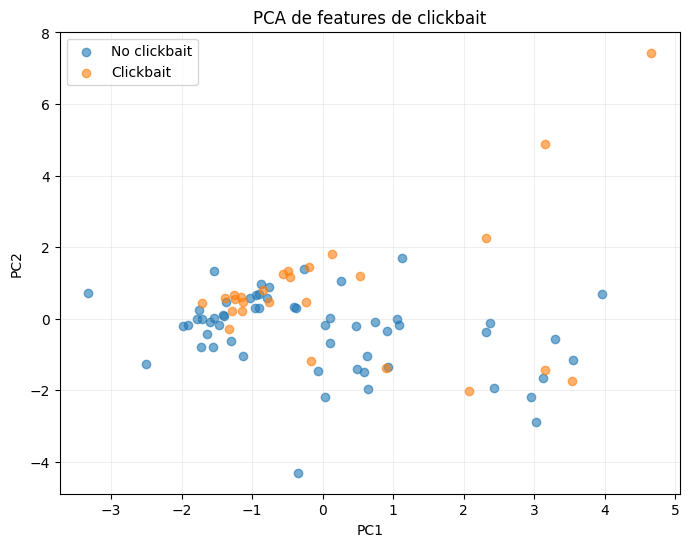

In [219]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[y==0, 0],
    X_pca[y==0, 1],
    label="No clickbait",
    alpha=0.6
)

plt.scatter(
    X_pca[y==1, 0],
    X_pca[y==1, 1],
    label="Clickbait",
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA de features de clickbait")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

/tmp/ipykernel_1613/2231787948.py:13: RuntimeWarning: invalid value encountered in log
  np.log(X_pca[clickbait == False, 1]/(1+X_pca[clickbait == False, 1])),
/tmp/ipykernel_1613/2231787948.py:27: RuntimeWarning: invalid value encountered in log
  np.log(X_pca[clickbait == True, 1]/(1+X_pca[clickbait == True, 1])),


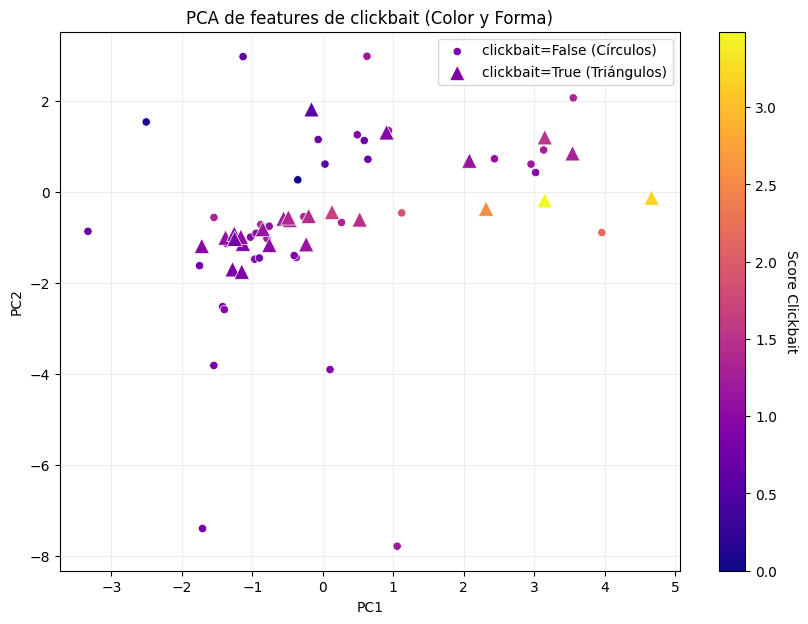

In [273]:
import matplotlib.pyplot as plt

# Extraemos los scores para el color y la columna de clickbait para las formas
colores = df["score_clickbait"].values
clickbait = df["clickbait"].values

plt.figure(figsize=(10, 7))

# 1. Graficamos los puntos que NO son clickbait (clickbait == False)
# Marcador 'o' (círculo)
scatter_false = plt.scatter(
    X_pca[clickbait == False, 0],
    np.log(X_pca[clickbait == False, 1]/(1+X_pca[clickbait == False, 1])),
    c=colores[clickbait == False],  # Solo scores de False
    cmap="plasma",
    vmin=min(colores), vmax=max(colores), # Mismo rango de color para ambos
    marker='o',                       # Círculo
    edgecolors='w',
    linewidth=0.5,
    label="clickbait=False (Círculos)"
)

# 2. Graficamos los puntos que SÍ son clickbait (clickbait == True)
# Marcador '^' (triángulo)
scatter_true = plt.scatter(
    X_pca[clickbait == True, 0],
    np.log(X_pca[clickbait == True, 1]/(1+X_pca[clickbait == True, 1])),
    c=colores[clickbait == True],   # Solo scores de True
    cmap="plasma",
    vmin=min(colores), vmax=max(colores), # Mismo rango de color para ambos
    marker='^',                       # Triángulo
    edgecolors='w',
    s=120,
    linewidth=0.5,
    label="clickbait=True (Triángulos)"
)

# Añadimos la barra de colores (utilizamos una para la escala unificada)
# Es necesario pasar un objeto 'mappable', por ejemplo, el segundo scatter
cbar = plt.colorbar(scatter_true)
cbar.set_label('Score Clickbait', rotation=270, labelpad=15)

# Añadimos la leyenda de marcadores
plt.legend()

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA de features de clickbait (Color y Forma)")
plt.grid(alpha=0.2)

plt.show()

In [267]:
import plotly.express as px
import pandas as pd

# 1. Preparamos un DataFrame temporal para Plotly
# Esto facilita que Plotly asocie cada punto con su título y score
df_plot = pd.DataFrame({
    'Dim 1': X_pca[:, 0], # O X_umap[:, 0]
    'Dim 2': X_pca[:, 1], # O X_umap[:, 1]
    'Score': df['score_clickbait'],
    'Es Clickbait': df['clickbait'].astype(str), # Convertimos a texto para la leyenda
    'Titulo': df['titulo']
})

# 2. Creamos el gráfico
fig = px.scatter(
    df_plot, 
    x='Dim 1', 
    y='Dim 2', 
    color='Score',           # Gradiente de color
    symbol='Es Clickbait',    # Forma diferente (Círculo/Diamante/etc)
    hover_name='Titulo',      # <--- ESTO hará que se vea el título al pasar el ratón
    hover_data={'Score': ':.2f', 'Es Clickbait': True, 'Dim 1': False, 'Dim 2': False},
    color_continuous_scale='plasma',
    title="Análisis Interactivo de Clickbait",
    labels={'Es Clickbait': '¿Es Clickbait?'}
)

# Ajustes de estilo
fig.update_traces(marker=dict(size=10, line=dict(width=0.5, color='White')))
fig.update_layout(template='plotly_white')

fig.show()

/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


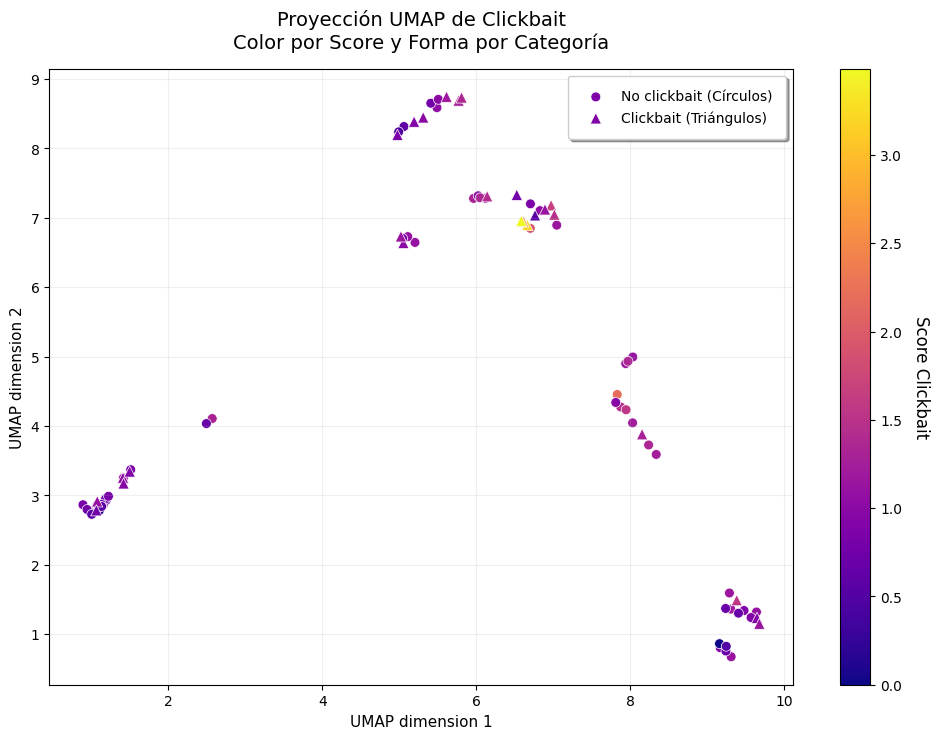

In [261]:
reducer = UMAP(
    n_neighbors=5,      # Valor bajo para resaltar grupos locales
    min_dist=0.01,       # Valor muy bajo para compactar los puntos
    n_components=5,
    metric="cosine",     # Excelente para features de texto/scores
    learning_rate=0.01,   # Ayuda a que la optimización sea más agresiva
    random_state=37
)

X_umap = reducer.fit_transform(X_scaled)
import matplotlib.pyplot as plt

# 1. Extraemos los datos necesarios
# Asegúrate de haber ejecutado antes: X_umap = reducer.fit_transform(X_scaled)
colores = df["score_clickbait"].values
clickbait = df["clickbait"].values

plt.figure(figsize=(12, 8))

# Definimos el rango de color para que sea igual en ambas categorías
vmin = colores.min()
vmax = colores.max()

# 2. Graficamos los 'False' (Círculos)
scatter_false = plt.scatter(
    X_umap[clickbait == False, 0],
    X_umap[clickbait == False, 1],
    c=colores[clickbait == False],
    cmap="plasma",
    vmin=vmin, vmax=vmax,
    marker='o',
    s=50,                # Tamaño del punto
    edgecolors='w',
    linewidth=0.5,
    label="No clickbait (Círculos)"
)

# 3. Graficamos los 'True' (Triángulos)
scatter_true = plt.scatter(
    X_umap[clickbait == True, 0],
    X_umap[clickbait == True, 1],
    c=colores[clickbait == True],
    cmap="plasma",
    vmin=vmin, vmax=vmax,
    marker='^',
    s=65,                # Un poco más grandes para que se vean bien los triángulos
    edgecolors='w',
    linewidth=0.5,
    label="Clickbait (Triángulos)"
)

# 4. Detalles estéticos y Colorbar
cbar = plt.colorbar(scatter_true)
cbar.set_label('Score Clickbait', rotation=270, labelpad=20, fontsize=12)

plt.legend(frameon=True, shadow=True, borderpad=1)
plt.xlabel("UMAP dimension 1", fontsize=11)
plt.ylabel("UMAP dimension 2", fontsize=11)
plt.title("Proyección UMAP de Clickbait\nColor por Score y Forma por Categoría", fontsize=14, pad=15)
plt.grid(alpha=0.2)

plt.show()

In [240]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=features
)

print(loadings)

                            PC1       PC2
score_clickbait        0.377918  0.472133
similitud_media       -0.138920 -0.167158
diferencia_ling_media  0.363878  0.486579
deicticos_titulo       0.129742  0.094628
puntuacion_titulo     -0.163080 -0.188859
superlativos_titulo    0.156691  0.321434
information_delay      0.452319 -0.381632
position_relevance     0.452319 -0.381632
early_late_ratio      -0.241437  0.090061
argmax_relevance       0.412330 -0.255048


### Question Answering (QA)

Convertir el titular en una pregunta con un transformers de QA y ver si encuentra la respuesta en qué frase del texto, si es al final del texto o no aparece puede dar indicios de clickbait



### Buscar si el cuerpo aporta más información (entropía)

Ver la redundaicia por párrafos, separar en porcentaje de texto que tenga, es decir, ver 0-25% la entropía, luego de 25-50% etc

Hipótesis: El contenido en noticias con clickbait tienen una tasa de redundancia muy alta. Dice mucho en el título y casi nada de información nueva en el contenido (entropía baja)


=== entropy_0_25 ===
       count      mean       std       min       25%       50%       75%  \
cb                                                                         
False   57.0  5.733474  0.768981  3.584963  5.421567  5.700946  6.199391   
True    26.0  5.991778  0.596593  4.734522  5.721646  5.871146  6.600665   

            max  
cb               
False  7.810647  
True   6.994491  

=== entropy_25_50 ===
       count      mean       std       min       25%       50%       75%  \
cb                                                                         
False   57.0  5.760509  0.836091  3.584963  5.277613  5.809184  6.333678   
True    26.0  6.074447  0.636452  4.829966  5.739915  6.008284  6.590306   

            max  
cb               
False  7.737697  
True   7.303311  

=== entropy_50_75 ===
       count      mean       std       min       25%       50%       75%  \
cb                                                                         
False   57.0  5.760698  0.

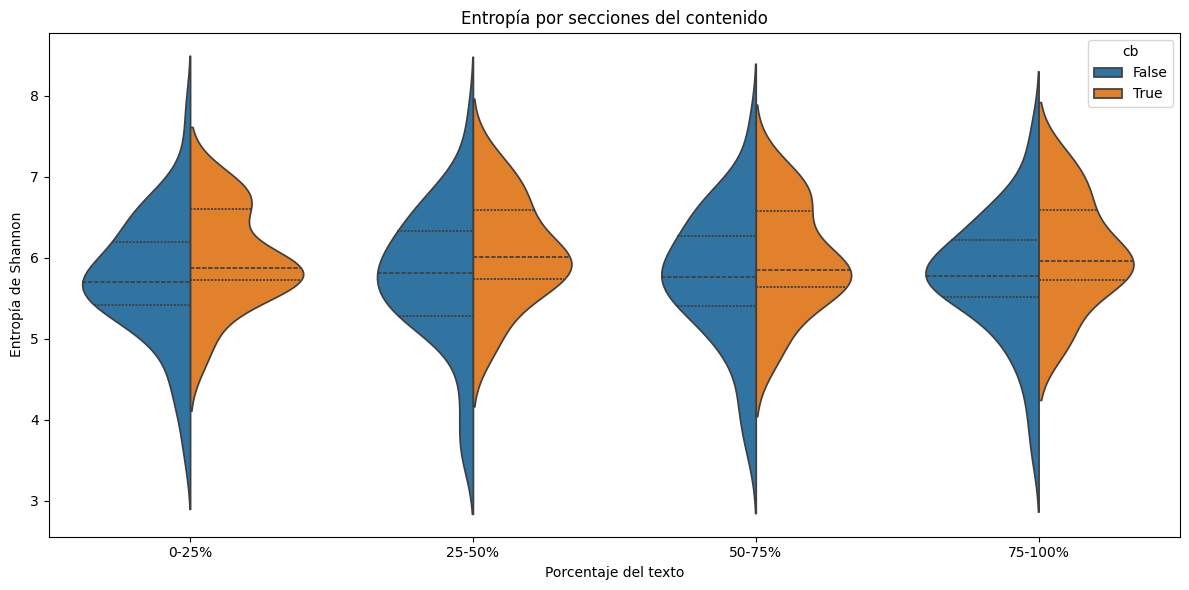

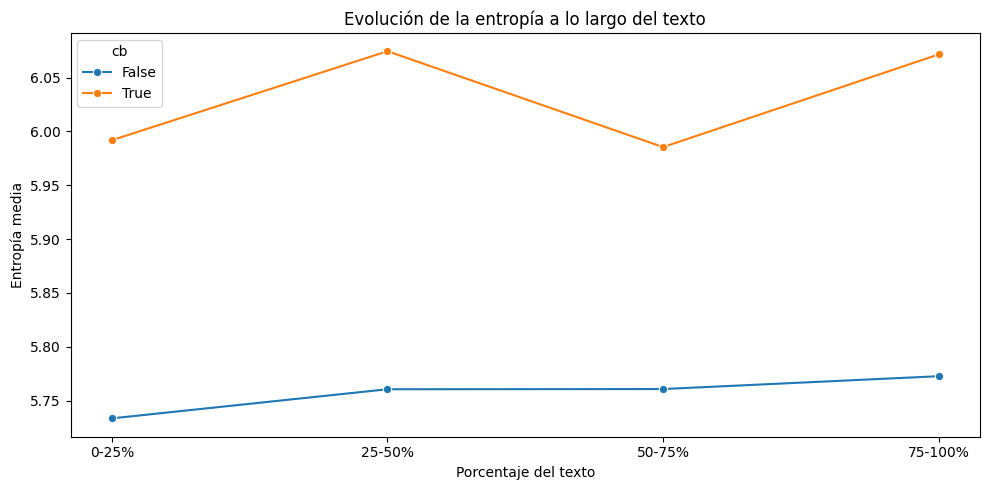

In [ ]:
import numpy as np
import pandas as pd
import re

from collections import Counter
from scipy.stats import mannwhitneyu

import seaborn as sns
import matplotlib.pyplot as plt


# ============================================================
# LIMPIEZA
# ============================================================

def limpiar_texto(texto):

    if not isinstance(texto, str):
        return ""

    texto = texto.lower()

    texto = re.sub(r"http\S+", "", texto)

    texto = re.sub(r"[^a-záéíóúñü\s]", " ", texto)

    texto = re.sub(r"\s+", " ", texto).strip()

    return texto


# ============================================================
# ENTROPÍA DE SHANNON
# ============================================================

def shannon_entropy(texto):

    texto = limpiar_texto(texto)

    palabras = texto.split()

    if len(palabras) < 2:
        return np.nan

    freqs = Counter(palabras)

    probs = np.array(list(freqs.values())) / len(palabras)

    H = -np.sum(probs * np.log2(probs))

    return H


# ============================================================
# DIVIDIR TEXTO EN TRAMOS
# ============================================================

def split_text_sections(texto, n_sections=4):

    texto = limpiar_texto(texto)

    palabras = texto.split()

    if len(palabras) < n_sections:
        return [texto]

    sections = []

    size = len(palabras) // n_sections

    for i in range(n_sections):

        start = i * size

        if i == n_sections - 1:
            end = len(palabras)
        else:
            end = (i + 1) * size

        section = " ".join(palabras[start:end])

        sections.append(section)

    return sections


# ============================================================
# ENTROPÍA POR SECCIONES
# ============================================================

def entropy_by_sections(texto):

    sections = split_text_sections(texto, n_sections=4)

    entropies = []

    for sec in sections:
        entropies.append(shannon_entropy(sec))

    return entropies


# ============================================================
# CALCULAR ENTROPÍAS
# ============================================================

entropy_sections = df["Contenido"].apply(entropy_by_sections)

df["entropy_0_25"] = entropy_sections.apply(lambda x: x[0])
df["entropy_25_50"] = entropy_sections.apply(lambda x: x[1])
df["entropy_50_75"] = entropy_sections.apply(lambda x: x[2])
df["entropy_75_100"] = entropy_sections.apply(lambda x: x[3])


# ============================================================
# RESUMEN ESTADÍSTICO
# ============================================================

cols = [
    "entropy_0_25",
    "entropy_25_50",
    "entropy_50_75",
    "entropy_75_100"
]

for col in cols:

    print(f"\n=== {col} ===")

    print(
        df.groupby("cb")[col].describe()
    )


# ============================================================
# TESTS ESTADÍSTICOS
# ============================================================

for col in cols:

    click = df[df["cb"] == True][col].dropna()
    noclick = df[df["cb"] == False][col].dropna()

    stat, p = mannwhitneyu(click, noclick)

    print(f"\n--- {col} ---")
    print("Statistic:", stat)
    print("p-value:", p)


# ============================================================
# PREPARAR DATAFRAME LARGO PARA PLOTS
# ============================================================

plot_df = df.melt(
    id_vars=["cb"],
    value_vars=cols,
    var_name="section",
    value_name="entropy"
)

plot_df["section"] = plot_df["section"].map({
    "entropy_0_25": "0-25%",
    "entropy_25_50": "25-50%",
    "entropy_50_75": "50-75%",
    "entropy_75_100": "75-100%"
})


# ============================================================
# VIOLIN PLOT
# ============================================================

plt.figure(figsize=(12,6))

sns.violinplot(
    data=plot_df,
    x="section",
    y="entropy",
    hue="cb",
    split=True,
    inner="quartile"
)

plt.title("Entropía por secciones del contenido")
plt.xlabel("Porcentaje del texto")
plt.ylabel("Entropía de Shannon")

plt.tight_layout()
plt.show()


# ============================================================
# EVOLUCIÓN MEDIA DE ENTROPÍA
# ============================================================

mean_df = plot_df.groupby(["section", "cb"])["entropy"].mean().reset_index()

plt.figure(figsize=(10,5))

sns.lineplot(
    data=mean_df,
    x="section",
    y="entropy",
    hue="cb",
    marker="o"
)

plt.title("Evolución de la entropía a lo largo del texto")
plt.xlabel("Porcentaje del texto")
plt.ylabel("Entropía media")

plt.tight_layout()
plt.show()